In [1]:
import pandas as pd
import numpy as np
import datamol as dm

# Potency

In [3]:
import polaris as po

# Load the dataset from the Hub
dataset = po.load_dataset("asap-discovery/antiviral-potency-2025-unblinded")

# Get information on the dataset size


Output()

[2025-10-30 11:27:38] INFO     The version of Polaris that was used to create the artifact          ]8;id=814367;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py\_artifact.py]8;;\:]8;id=522327;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py#92\92]8;;\
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.11.7).                                              

                      WARNING  You're loading data from a remote location. If the dataset is small     ]8;id=62898;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py\_base.py]8;;\:]8;id=257028;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py#182\182]8;;\
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[11:27:39]  Success: Fetching dataset                                                                 ]8;id=416470;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py\context.py]8;;\:]8;id=808173;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py#53\53]8;;\

In [4]:
data = pd.DataFrame(dataset[:])

In [5]:
def set_created_time_bins(created_date):
    # given a date in yyyy-mm-dd format, set the generalized date
    if created_date.split("-")[0] == "2022":
        return "2022"
    elif created_date.split("-")[0] == "2023" or created_date.split("-")[0] == "2024": # for 2023 and 2024 just do Q1+2 or Q3+4
        if int(created_date.split("-")[1]) <= 6:
            return f"{created_date.split('-')[0]}Q1+2"
        else:
            return f"{created_date.split('-')[0]}Q3+4"
    else:
        raise ValueError(f"No compounds were synthesized in {created_date}")

In [8]:
test = data.query("Set == 'Test'")

In [9]:
test["Molecule Name"]

1031    ASAP-0000175
1032    ASAP-0000272
1033    ASAP-0000528
1034    ASAP-0000541
1035    ASAP-0000733
            ...     
1323    ASAP-0032561
1324    ASAP-0032562
1325    ASAP-0032572
1326    ASAP-0032604
1327    ASAP-0032605
Name: Molecule Name, Length: 297, dtype: object

In [10]:
train = data.query("Set == 'Train'")
train

,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
0,COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...,ASAP-0000141,Train,4.19,NaN
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
2,CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...,ASAP-0000143,Train,4.73,NaN
3,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000144,Train,4.90,6.11
4,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000145,Train,4.81,5.62
...,...,...,...,...,...
1026,CNS(=O)(=O)OCC(=O)N1CCN(CC2=CC=CC(Cl)=C2)[C@H]...,ASAP-0031916,Train,5.57,6.38
1027,O=C(CC1=CN=CC2=CC=CC=C12)N1CC[C@@H]2CCCC[C@H]2...,ASAP-0031917,Train,4.60,6.09
1028,CNC(=O)[C@H]1CCCN(C(=O)CC2=CN=CC3=CC=CC=C23)C1...,ASAP-0031918,Train,4.22,NaN
1029,C[C@H]1CCCN(C(=O)CC2=CN=CC3=CC=CC=C23)[C@H]1C ...,ASAP-0031920,Train,4.40,5.06


In [11]:
mols = np.array([dm.to_mol(smi) for smi in data["CXSMILES"]])
train_indices = data.index[data["Set"] == "Train"].tolist()
test_indices = data.index[data["Set"] == "Test"].tolist()


In [ ]:
y_true = {
    "pIC50 (MERS-CoV Mpro)": test["pIC50 (MERS-CoV Mpro)"].to_numpy(),
    "pIC50 (SARS-CoV-2 Mpro)": test["pIC50 (SARS-CoV-2 Mpro)"].to_numpy()
}

In [14]:

from evaluation.potency import evaluate_potency_predictions, evaluate_all_potency_predictions

In [15]:
submissions = pd.read_json("./latest_competition_prediction.json")

In [16]:
def determine_subchallenge(data):
    sub = data["test"]
    if "Ligand Pose" in sub.keys():
        challenge = "Ligand Pose"
    elif "pIC50 (MERS-CoV Mpro)" and "pIC50 (SARS-CoV-2 Mpro)" in sub.keys():
        challenge = "Potency"
    elif "HLM" and "MLM" in sub.keys():
        challenge = "ADMET"
    else:
        raise ValueError()
    return challenge
        

In [17]:
submissions["subchallenge"] = submissions["predictions"].apply(determine_subchallenge)
submissions["predictions_unnested"] = submissions["predictions"].apply(lambda x: x["test"])

In [18]:
potency_submissions = submissions.query("subchallenge == 'Potency'")

In [19]:
potency_compact = potency_submissions[["id","predictions_unnested"]].set_index("id")

In [20]:
potency_compact_dict = potency_compact.to_dict()["predictions_unnested"]

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [22]:
potency_submissions

,id,created_at,deleted_at,name,slug,description,tags,user_attributes,access,is_certified,...,polaris_version,owner_id,creator_id,competition_id,predictions,results,github_url,report_url,subchallenge,predictions_unnested
0,competition-prediction-qg5PVWDLbiN5ndytwYPta,2025-02-26 16:31:25.637415+00:00,NaT,BALM_potency_few_shot,balm-potency-few-shot,"BALM, few shot learning",[],{'Method': 'BALM'},public,False,...,0.11.8,8ZKQKFE9xTEUExcMaJNg4,8ZKQKFE9xTEUExcMaJNg4,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [4.96794986...,"[{'scores': {'CLD': 't', 'R²': '0.194 ± 0.038'...",None,https://github.com/meyresearch/polaris_challen...,Potency,"{'pIC50 (MERS-CoV Mpro)': [4.967949867248535, ..."
1,competition-prediction-a9l9rEDGgw5wDcnMn3fud,2025-03-13 20:56:51.741258+00:00,NaT,asapdiscovery_ml_gat,asapdiscovery-ml-gat,Predictions made by a GAT model trained using ...,[],"{'Model': 'GAT', 'Framework': 'asapdiscovery-m...",public,False,...,0.11.9,AEMymAUQxGDjos3FzZ8E5,AEMymAUQxGDjos3FzZ8E5,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [5.55951023...,"[{'scores': {'CLD': 'p', 'R²': '0.313 ± 0.046'...",https://github.com/kaminow/asap-polaris-challe...,https://github.com/kaminow/asap-polaris-challe...,Potency,"{'pIC50 (MERS-CoV Mpro)': [5.559510231018066, ..."
2,competition-prediction-JMFyxShsgcjYFnRzZQFFK,2025-03-13 16:28:10.171798+00:00,NaT,potency-prediction,potency-prediction,Predictions from potency-prediction-pipeline u...,"[rdkit, ensemble, scaffold-split]",{},public,False,...,0.11.9,C7ibMkBrX6uTYUKUyMANu,C7ibMkBrX6uTYUKUyMANu,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [5.34203960...,"[{'scores': {'CLD': 'f', 'R²': '0.575 ± 0.039'...",https://github.com/fulopjoz/polaris-antiviral-...,https://tinyurl.com/dodo-potency,Potency,"{'pIC50 (MERS-CoV Mpro)': [5.342039601550117, ..."
3,competition-prediction-pr9pVVQedDD3mD0WXrWMg,2025-03-13 23:45:22.831273+00:00,NaT,ucbbind,ucbbind,ucbbind first submission,[potency-predict],{'Method': '1D-CNN + KNN for nearest neighbor ...,public,False,...,0.11.7,DXCx5ew2mA9psvLPwBYmv,DXCx5ew2mA9psvLPwBYmv,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [5.45914277...,"[{'scores': {'CLD': 'q', 'R²': '0.319 ± 0.045'...",https://github.com/KSUN63/Polaris-Submission,https://docs.google.com/document/d/1YVxVi-zMc7...,Potency,"{'pIC50 (MERS-CoV Mpro)': [5.459142773, 5.2773..."
4,competition-prediction-ReoR53l5wBTRr6Py011Fn,2025-03-14 07:28:13.271737+00:00,NaT,Physics_Informed_Linear_Model_pIC50_Prediction,physics-informed-linear-model-pic50-prediction,Submission of predicted pIC50 values for MERS-...,"[MERS-CoV, SARS-CoV-2, pIC50, Linear Regressio...",{},public,False,...,0.11.8,EvkoUyLA330ffFW9K7uuM,EvkoUyLA330ffFW9K7uuM,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [5.02625437...,"[{'scores': {'CLD': 's', 'R²': '0.299 ± 0.041'...",None,https://drive.google.com/file/d/1xrmgHAFcyRDAG...,Potency,"{'pIC50 (MERS-CoV Mpro)': [5.026254372138071, ..."
5,competition-prediction-LTj8nDyZE1cYCYaRzVols,2025-03-12 07:34:30.777033+00:00,NaT,potency-tabPFN,potency-tabpfn,Source code and report will be made public onc...,[],"{'Method': 'thresholded nearest neighbor', 'Fr...",public,False,...,0.11.9,MJfl29Yy4boyjo7TzpRHq,MJfl29Yy4boyjo7TzpRHq,competition-2np7VaBJ3aZlRSho6iJsp,{'test': {'pIC50 (MERS-CoV Mpro)': [5.30970382...,"[{'scores': {'CLD': 'h', 'R²': '0.570 ± 0.036'...",https://github.com/dehaenw/polaris-baseline,https://molecular.beauty/blog/2025/03/13/polar...,Potency,"{'pIC50 (MERS-CoV Mpro)': [5.309703826904297, ..."
6,competition-prediction-blnBskG8gooYdhc29wEuu,2025-03-14 01:09:56.625582+00:00,NaT,fps_gnn_mmoe,fps-gnn-mmoe,GNN+MMoE model using molecular fingerprints wi...,[],"{'Method': 'GNN+MMoE+fps', 'Framework': 'pytor...",public,False,...,0.11.0,Mbyuw4vGTa1jaNfmT7r7S,Mbyuw4vGTa1jaNfmT7r7S,competition-2np7VaBJ3aZlRSho6iJsp,"{'test': {'pIC50 (MERS-CoV Mpro)': [5.4399886,...","[{'scores': {'CLD': 'bc', 'R²':

We're going to split up the eval into lead and backup series. First we need to split up y_true and all participant entries into lead/backup, then we can continue on with viz.

In [34]:
from rdkit import Chem
lead = Chem.MolFromSmiles("O=C1CCCN1c(cnc2)c3c2cccc3")
backup = Chem.MolFromSmiles("NC(CC1=CN=CC2=CC=CC=C12)=O")
## Write out scaffolds
scaffs = {"lead": lead, "backup": backup}

def get_series(mol):
    if mol.HasSubstructMatch(scaffs["lead"]):
        return "Lead"
    if mol.HasSubstructMatch(scaffs["backup"]):
        return "Backup"
    else:
        return "Misc"


In [77]:
lead_indices = []
backup_indices = []
misc_indices = []
for i, (smi, pic50) in enumerate(test[["CXSMILES", "pIC50 (MERS-CoV Mpro)"]].values):
    series = get_series(Chem.MolFromSmiles(smi))
    if series == "Lead":
        lead_indices.append(i)
    elif series == "Backup":
        backup_indices.append(i)
    else:
        misc_indices.append(i)


In [78]:
y_true_lead = {}
for tgt, vals in y_true.items():
    y_true_lead[tgt] = [vals[i] for i in lead_indices]

y_true_backup = {}
for tgt, vals in y_true.items():
    y_true_backup[tgt] = [vals[i] for i in backup_indices]

y_true_misc = {}
for tgt, vals in y_true.items():
    y_true_misc[tgt] = [vals[i] for i in misc_indices]

In [79]:
potency_compact_dict_lead = {}
for entry, data in potency_compact_dict.items():
    potency_compact_dict_lead[entry] = {}
    for tgt, vals in data.items():
        potency_compact_dict_lead[entry][tgt] = [vals[i] for i in lead_indices]

potency_compact_dict_backup = {}
for entry, data in potency_compact_dict.items():
    potency_compact_dict_backup[entry] = {}
    for tgt, vals in data.items():
        potency_compact_dict_backup[entry][tgt] = [vals[i] for i in backup_indices]

potency_compact_dict_misc = {}
for entry, data in potency_compact_dict.items():
    potency_compact_dict_misc[entry] = {}
    for tgt, vals in data.items():
        potency_compact_dict_misc[entry][tgt] = [vals[i] for i in misc_indices]


In [80]:
main_lead, leaderboards_lead = evaluate_all_potency_predictions(y_true_lead, potency_compact_dict_lead, "mean_absolute_error", ascending=True)
main_backup, leaderboards_backup = evaluate_all_potency_predictions(y_true_backup, potency_compact_dict_backup, "mean_absolute_error", ascending=True)
main_misc, leaderboards_misc = evaluate_all_potency_predictions(y_true_misc, potency_compact_dict_misc, "mean_absolute_error", ascending=True)



eval competition-prediction-qg5PVWDLbiN5ndytwYPta
eval competition-prediction-a9l9rEDGgw5wDcnMn3fud
eval competition-prediction-JMFyxShsgcjYFnRzZQFFK
eval competition-prediction-pr9pVVQedDD3mD0WXrWMg
eval competition-prediction-ReoR53l5wBTRr6Py011Fn
eval competition-prediction-LTj8nDyZE1cYCYaRzVols
eval competition-prediction-blnBskG8gooYdhc29wEuu
eval competition-prediction-Urln41KPESzYx2ao4tGbC
eval competition-prediction-wNi5FK6MaefmrF2LqbFr6
eval competition-prediction-u6GoQ1bnenK7gjAHUdmrb
eval competition-prediction-9Yrcg7omjLhpejG2mfZXp
eval competition-prediction-NJdr6C8caPRWhUp0KSA4J
eval competition-prediction-FRAbKFdXri7jeiwx2u81Z
eval competition-prediction-YbG9mZ88TW0VZyLxXbthw
eval competition-prediction-A5j8QDEsevsGLLhzPGNh2
eval competition-prediction-4j4z6oqcwr72GzgT4cQ6R
eval competition-prediction-fTl3CZi7ZKnrswuuFasqs
eval competition-prediction-64eAZRW5acEnQ4QZfrrVB
eval competition-prediction-5RJGGvBhxyKc5YjHbsb0g
eval competition-prediction-FLUT3zC27jxaWLpo6Aoge


/Users/jenkescheen/micromamba/envs/polaris/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Found 408 significantly different pairs


100%|██████████| 408/408 [00:00<00:00, 15639.23it/s]

doing CLD pIC50 (MERS-CoV Mpro)


Found 434 significantly different pairs


100%|██████████| 434/434 [00:00<00:00, 32968.59it/s]

doing CLD pIC50 (SARS-CoV-2 Mpro)


Found 417 significantly different pairs


100%|██████████| 417/417 [00:00<00:00, 34155.30it/s]


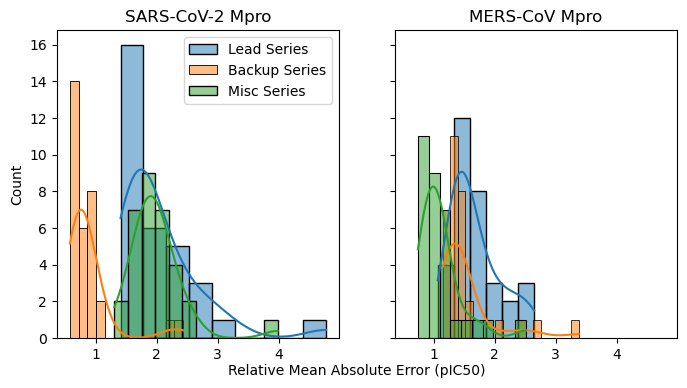

In [111]:
import seaborn as sns
from scipy import stats 

f, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)

mers_lead_mad = stats.median_abs_deviation([ val for val in y_true_lead["pIC50 (MERS-CoV Mpro)"] if val > 0 ])
sars2_lead_mad = stats.median_abs_deviation([ val for val in y_true_lead["pIC50 (SARS-CoV-2 Mpro)"] if val > 0 ])

mers_backup_mad = stats.median_abs_deviation([ val for val in y_true_backup["pIC50 (MERS-CoV Mpro)"] if val > 0 ])
sars2_backup_mad = stats.median_abs_deviation([ val for val in y_true_backup["pIC50 (SARS-CoV-2 Mpro)"] if val > 0 ])

mers_misc_mad = stats.median_abs_deviation([ val for val in y_true_misc["pIC50 (MERS-CoV Mpro)"] if val > 0 ])
sars2_misc_mad = stats.median_abs_deviation([ val for val in y_true_misc["pIC50 (SARS-CoV-2 Mpro)"] if val > 0 ])


sns.histplot(leaderboards_lead['pIC50 (SARS-CoV-2 Mpro)']['mean_absolute_error_raw']/sars2_lead_mad, ax=axes[0], kde=True, label="Lead Series")
sns.histplot(leaderboards_backup['pIC50 (SARS-CoV-2 Mpro)']['mean_absolute_error_raw']/sars2_backup_mad, ax=axes[0], kde=True, label="Backup Series")
sns.histplot(leaderboards_misc['pIC50 (SARS-CoV-2 Mpro)']['mean_absolute_error_raw']/sars2_misc_mad, ax=axes[0], kde=True, label="Misc Series")

sns.histplot(leaderboards_lead['pIC50 (MERS-CoV Mpro)']['mean_absolute_error_raw']/mers_lead_mad, ax=axes[1], kde=True, label="Lead Series")
sns.histplot(leaderboards_backup['pIC50 (MERS-CoV Mpro)']['mean_absolute_error_raw']/mers_backup_mad, ax=axes[1], kde=True, label="Backup Series")
sns.histplot(leaderboards_misc['pIC50 (MERS-CoV Mpro)']['mean_absolute_error_raw']/mers_misc_mad, ax=axes[1], kde=True, label="Misc Series")

for ax in axes:
    ax.set_xlabel("")
f.supxlabel("Relative Mean Absolute Error (pIC50)", size=10)
axes[0].legend()
axes[0].set_title("SARS-CoV-2 Mpro")
axes[1].set_title("MERS-CoV Mpro")


plt.savefig("potency_performance_per_chemical_series.png", dpi=300)